# Domain Adaptation: 5 Methods Comparison

Compared:
1. **MMD** (Maximum Mean Discrepancy): Distribution matching via kernel
2. **CORAL** (Covariance Alignment): Covariance matrix alignment
3. **DANN** (Domain Adversarial Neural Networks): Adversarial learning
4. **CDAN** (Conditional Domain Adversarial Networks): Class-conditional adversarial
5. **Importance Weighting**: Density ratio reweighting

Metrics: Spearman ρ, R², RMSE

In [11]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = r'..'
RESULTS_BASE = os.path.join(ROOT, 'results')
PROPERTIES = ['clearance', 'half_life', 'fu']

# Tuning result directories
METHODS = {
    'MMD': os.path.join(RESULTS_BASE, 'mmd_tuning'),
    'CORAL': os.path.join(RESULTS_BASE, 'coral_tuning'),
    'DANN': os.path.join(RESULTS_BASE, 'dann_tuning'),
    'CDAN': os.path.join(RESULTS_BASE, 'cdan_tuning'),
    'Importance Weighting': os.path.join(RESULTS_BASE, 'importance_weighting_tuning'),
}

print("="*100)
print("Domain Adaptation: 5 Methods Comparison")
print("="*100)
print("\nMethods:")
for method, path in METHODS.items():
    print(f"  - {method}: {path}")
print(f"\nProperties: {PROPERTIES}\n")

Domain Adaptation: 5 Methods Comparison

Methods:
  - MMD: ..\results\mmd_tuning
  - CORAL: ..\results\coral_tuning
  - DANN: ..\results\dann_tuning
  - CDAN: ..\results\cdan_tuning
  - Importance Weighting: ..\results\importance_weighting_tuning

Properties: ['clearance', 'half_life', 'fu']



In [12]:
# Load tuning results from all methods
all_results = {}

for method, path in METHODS.items():
    json_path = os.path.join(path, 'tuning_results.json')
    
    if os.path.exists(json_path):
        with open(json_path, 'r') as f:
            all_results[method] = json.load(f)
        print(f"✓ Loaded {method} results")
    else:
        print(f"✗ {method} results not found at {json_path}")

print(f"\nTotal methods loaded: {len(all_results)}/{len(METHODS)}")

✓ Loaded MMD results
✓ Loaded CORAL results
✓ Loaded DANN results
✓ Loaded CDAN results
✓ Loaded Importance Weighting results

Total methods loaded: 5/5


In [13]:
# Extract best performance for each method/property
best_performance = {}

for prop in PROPERTIES:
    best_performance[prop] = {}
    
    for method, results in all_results.items():
        if prop not in results:
            continue
        
        prop_results = results[prop]
        
        # λ is selected by val R² (test metrics are for reporting)
        best_r2 = -1
        best_weight = None
        best_metrics = None
        
        for weight_str, metrics in prop_results.items():
            r2 = metrics['val_r2_mean']
            if r2 > best_r2:
                best_r2 = r2
                best_weight = float(weight_str)
                best_metrics = metrics
        
        best_performance[prop][method] = {
            'best_weight': best_weight,
            'rho_mean': best_metrics['rho_mean'],
            'rho_std': best_metrics['rho_std'],
            'r2_mean': best_metrics['r2_mean'],
            'r2_std': best_metrics['r2_std'],
            'rmse_mean': best_metrics['rmse_mean'],
            'rmse_std': best_metrics['rmse_std'],
        }

# Include the baseline (target-only) in the comparison table too
for prop in PROPERTIES:
    base_path = os.path.join(RESULTS_BASE, f'01_baseline_{prop}.csv')
    if os.path.exists(base_path):
        b = pd.read_csv(base_path)
        best_performance[prop]['Baseline'] = {
            'best_weight': float('nan'),
            'rho_mean': float(b['spearman_rho'].mean()), 'rho_std': float(b['spearman_rho'].std()),
            'r2_mean': float(b['r2'].mean()), 'r2_std': float(b['r2'].std()),
            'rmse_mean': float(b['rmse'].mean()), 'rmse_std': float(b['rmse'].std()),
        }

print("✓ Extracted best performance for each method/property (λ selected by val R²)")

✓ Extracted best performance for each method/property (λ selected by val R²)


In [14]:
# Print detailed comparison table
print("\n" + "="*120)
print("BEST PERFORMANCE BY METHOD (Sorted by R²)")
print("="*120 + "\n")

for prop in PROPERTIES:
    print(f"\n{prop.upper()}:")
    print(f"  {'Method':<20} {'Weight':<10} {'Spearman ρ':<20} {'R²':<20} {'RMSE':<20}")
    print(f"  {'-'*90}")
    
    # Sort by R²
    sorted_methods = sorted(
        best_performance[prop].items(),
        key=lambda x: x[1]['r2_mean'],
        reverse=True
    )
    
    for rank, (method, metrics) in enumerate(sorted_methods, 1):
        rho_str = f"{metrics['rho_mean']:.4f}±{metrics['rho_std']:.4f}"
        r2_str = f"{metrics['r2_mean']:.4f}±{metrics['r2_std']:.4f}"
        rmse_str = f"{metrics['rmse_mean']:.4f}±{metrics['rmse_std']:.4f}"
        weight_str = f"{metrics['best_weight']:.2f}"
        
        medal = {1: '🥇', 2: '🥈', 3: '🥉'}.get(rank, '  ')
        print(f"  {medal} {method:<18} {weight_str:<10} {rho_str:<20} {r2_str:<20} {rmse_str:<20}")


BEST PERFORMANCE BY METHOD (Sorted by R²)


CLEARANCE:
  Method               Weight     Spearman ρ           R²                   RMSE                
  ------------------------------------------------------------------------------------------
  🥇 MMD                0.10       0.3688±0.0424        0.1027±0.0398        0.9449±0.0953       
  🥈 CDAN               0.50       0.3453±0.0512        0.1014±0.0395        0.9450±0.0873       
  🥉 Baseline           nan        0.3599±0.0839        0.0891±0.0619        0.9514±0.0928       
     CORAL              0.01       0.3595±0.0525        0.0871±0.0525        0.9520±0.0830       
     Importance Weighting 1.00       0.3456±0.0615        0.0721±0.0479        0.9604±0.0921       
     DANN               0.01       0.3354±0.0612        0.0661±0.0616        0.9636±0.0968       

HALF_LIFE:
  Method               Weight     Spearman ρ           R²                   RMSE                
  --------------------------------------------------------

In [15]:
# Create comparison DataFrame
comparison_data = []

for prop in PROPERTIES:
    for method, metrics in best_performance[prop].items():
        comparison_data.append({
            'Property': prop,
            'Method': method,
            'Best Weight': metrics['best_weight'],
            'Spearman ρ': metrics['rho_mean'],
            'R²': metrics['r2_mean'],
            'RMSE': metrics['rmse_mean'],
        })

comparison_df = pd.DataFrame(comparison_data)

# Summary statistics
print(f"\n\n{'='*100}")
print("OVERALL RANKING BY AVERAGE R²")
print(f"{'='*100}\n")

method_avg = comparison_df.groupby('Method')['R²'].agg(['mean', 'std', 'min', 'max'])
method_avg = method_avg.sort_values('mean', ascending=False)

print(method_avg.to_string())

print(f"\n\n{'='*100}")
print("AVERAGE SPEARMAN ρ BY METHOD")
print(f"{'='*100}\n")

rho_avg = comparison_df.groupby('Method')['Spearman ρ'].agg(['mean', 'std', 'min', 'max'])
rho_avg = rho_avg.sort_values('mean', ascending=False)

print(rho_avg.to_string())



OVERALL RANKING BY AVERAGE R²

                          mean       std       min       max
Method                                                      
CDAN                  0.160191  0.130484  0.069477  0.309732
Baseline              0.154888  0.079963  0.089055  0.243872
MMD                   0.151294  0.079162  0.102665  0.242639
CORAL                 0.131728  0.093944  0.068442  0.239671
Importance Weighting  0.122794  0.081405  0.072143  0.216695
DANN                  0.115221  0.084075  0.066133  0.212301


AVERAGE SPEARMAN ρ BY METHOD

                          mean       std       min       max
Method                                                      
Baseline              0.452157  0.114776  0.359898  0.580687
MMD                   0.451333  0.106851  0.368760  0.572014
CDAN                  0.447942  0.144143  0.345275  0.612729
CORAL                 0.447625  0.121822  0.359485  0.586637
DANN                  0.443242  0.131641  0.335409  0.589940
Importance Weighting

In [16]:
# Property-wise ranking
print(f"\n\n{'='*100}")
print("RANKING BY PROPERTY")
print(f"{'='*100}\n")

for prop in PROPERTIES:
    prop_df = comparison_df[comparison_df['Property'] == prop].sort_values('R²', ascending=False)
    print(f"\n{prop.upper()} Rankings:")
    for rank, (_, row) in enumerate(prop_df.iterrows(), 1):
        medal = {1: '🥇', 2: '🥈', 3: '🥉'}.get(rank, '  ')
        print(f"  {medal} #{rank}. {row['Method']:<20} R²={row['R²']:.4f}, ρ={row['Spearman ρ']:.4f}, RMSE={row['RMSE']:.4f}")



RANKING BY PROPERTY


CLEARANCE Rankings:
  🥇 #1. MMD                  R²=0.1027, ρ=0.3688, RMSE=0.9449
  🥈 #2. CDAN                 R²=0.1014, ρ=0.3453, RMSE=0.9450
  🥉 #3. Baseline             R²=0.0891, ρ=0.3599, RMSE=0.9514
     #4. CORAL                R²=0.0871, ρ=0.3595, RMSE=0.9520
     #5. Importance Weighting R²=0.0721, ρ=0.3456, RMSE=0.9604
     #6. DANN                 R²=0.0661, ρ=0.3354, RMSE=0.9636

HALF_LIFE Rankings:
  🥇 #1. Baseline             R²=0.1317, ρ=0.4159, RMSE=0.9259
  🥈 #2. MMD                  R²=0.1086, ρ=0.4132, RMSE=0.9362
  🥉 #3. Importance Weighting R²=0.0795, ρ=0.3801, RMSE=0.9520
     #4. CDAN                 R²=0.0695, ρ=0.3858, RMSE=0.9548
     #5. CORAL                R²=0.0684, ρ=0.3968, RMSE=0.9539
     #6. DANN                 R²=0.0672, ρ=0.4044, RMSE=0.9555

FU Rankings:
  🥇 #1. CDAN                 R²=0.3097, ρ=0.6127, RMSE=0.8160
  🥈 #2. Baseline             R²=0.2439, ρ=0.5807, RMSE=0.8481
  🥉 #3. MMD                  R²=0.2426, ρ=0.572

In [17]:
# Save comparison results
output_dir = os.path.join(RESULTS_BASE, 'comparison')
os.makedirs(output_dir, exist_ok=True)

# Save as CSV
comparison_df.to_csv(os.path.join(output_dir, 'methods_comparison.csv'), index=False)
print(f"✓ Comparison table saved to {os.path.join(output_dir, 'methods_comparison.csv')}")

# Save method averages
method_avg.to_csv(os.path.join(output_dir, 'method_averages.csv'))
print(f"✓ Method averages saved to {os.path.join(output_dir, 'method_averages.csv')}")

# Save as JSON
with open(os.path.join(output_dir, 'best_performance.json'), 'w') as f:
    json.dump(best_performance, f, indent=2)
print(f"✓ Best performance saved to {os.path.join(output_dir, 'best_performance.json')}")

✓ Comparison table saved to ..\results\comparison\methods_comparison.csv
✓ Method averages saved to ..\results\comparison\method_averages.csv
✓ Best performance saved to ..\results\comparison\best_performance.json


✓ R² comparison plot saved


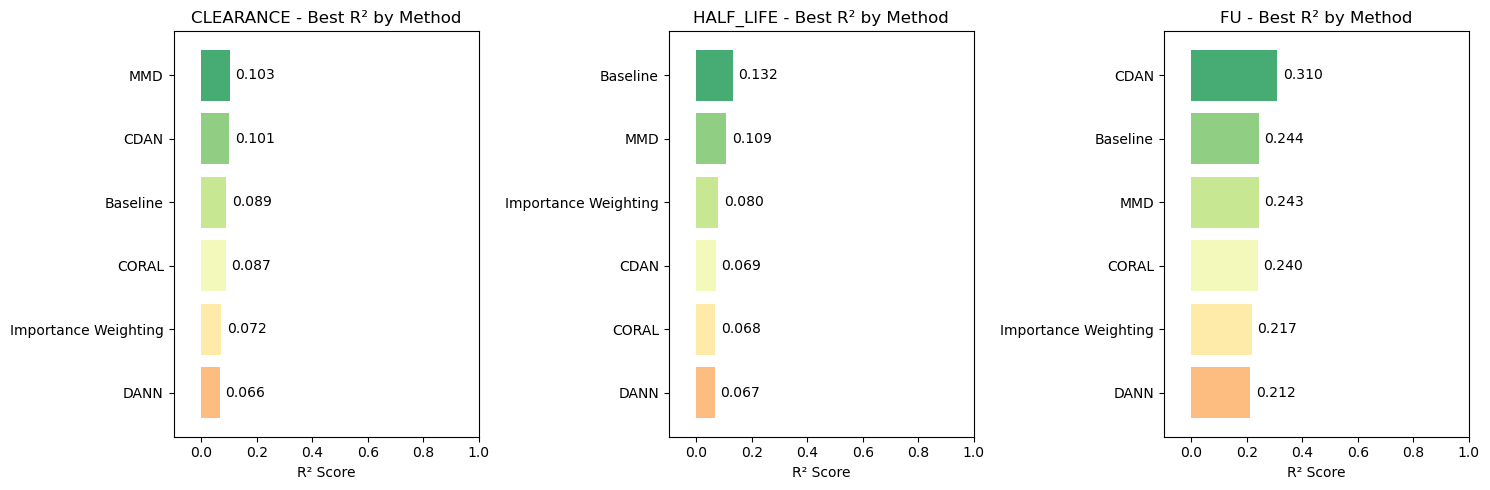

In [18]:
# Visualization: R² comparison by property
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, prop in enumerate(PROPERTIES):
    prop_df = comparison_df[comparison_df['Property'] == prop]
    prop_df_sorted = prop_df.sort_values('R²', ascending=True)
    
    colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(prop_df_sorted)))
    axes[idx].barh(prop_df_sorted['Method'], prop_df_sorted['R²'], color=colors, alpha=0.8)
    axes[idx].set_xlabel('R² Score')
    axes[idx].set_title(f'{prop.upper()} - Best R² by Method')
    axes[idx].set_xlim([-0.1, 1.0])
    
    # Add value labels
    for i, (method, r2) in enumerate(zip(prop_df_sorted['Method'], prop_df_sorted['R²'])):
        axes[idx].text(r2 + 0.02, i, f'{r2:.3f}', va='center')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'r2_comparison.png'), dpi=300, bbox_inches='tight')
print(f"✓ R² comparison plot saved")
plt.show()

✓ Metrics heatmap saved


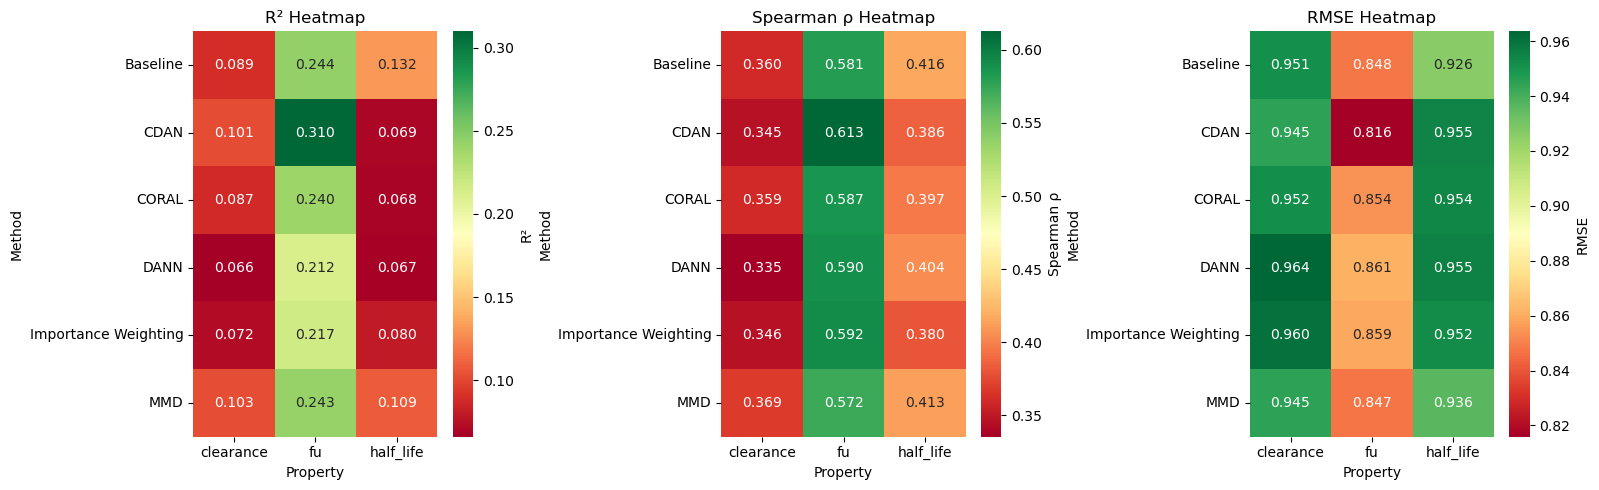

In [19]:
# Visualization: All metrics heatmap
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['R²', 'Spearman ρ', 'RMSE']

for idx, metric in enumerate(metrics):
    # Create pivot table
    pivot_df = comparison_df.pivot_table(
        index='Method',
        columns='Property',
        values=metric
    )
    
    # Normalize RMSE for better visualization (lower is better, so invert)
    if metric == 'RMSE':
        plot_data = pivot_df.copy()
    else:
        plot_data = pivot_df.copy()
    
    sns.heatmap(plot_data, annot=True, fmt='.3f', cmap='RdYlGn', ax=axes[idx], cbar_kws={'label': metric})
    axes[idx].set_title(f'{metric} Heatmap')
    axes[idx].set_ylabel('Method')
    axes[idx].set_xlabel('Property')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, 'metrics_heatmap.png'), dpi=300, bbox_inches='tight')
print(f"✓ Metrics heatmap saved")
plt.show()

In [20]:
# Final recommendations
print("\n" + "="*100)
print("RECOMMENDATIONS")
print("="*100 + "\n")

print("🏆 OVERALL BEST METHOD (by average R²):")
best_method = method_avg.index[0]
print(f"   {best_method} (R² = {method_avg.iloc[0]['mean']:.4f} ± {method_avg.iloc[0]['std']:.4f})")

print("\n📊 PROPERTY-SPECIFIC RECOMMENDATIONS:")
for prop in PROPERTIES:
    prop_df = comparison_df[comparison_df['Property'] == prop]
    best_idx = prop_df['R²'].idxmax()
    best_row = prop_df.loc[best_idx]
    print(f"\n   {prop.upper()}:")
    print(f"      Method: {best_row['Method']}")
    print(f"      Best Weight: {best_row['Best Weight']:.2f}")
    print(f"      R²: {best_row['R²']:.4f}")
    print(f"      Spearman ρ: {best_row['Spearman ρ']:.4f}")
    print(f"      RMSE: {best_row['RMSE']:.4f}")

print("\n⚖️ TRADE-OFFS:")
print("   - CORAL: Simple, fast, stable")
print("   - MMD: Good for distribution matching")
print("   - DANN: Powerful but requires careful tuning")
print("   - CDAN: Class-conditional, good for imbalanced domains")
print("   - Importance Weighting: Lightweight, KDE-based")

print("\n" + "="*100)


RECOMMENDATIONS

🏆 OVERALL BEST METHOD (by average R²):
   CDAN (R² = 0.1602 ± 0.1305)

📊 PROPERTY-SPECIFIC RECOMMENDATIONS:

   CLEARANCE:
      Method: MMD
      Best Weight: 0.10
      R²: 0.1027
      Spearman ρ: 0.3688
      RMSE: 0.9449

   HALF_LIFE:
      Method: Baseline
      Best Weight: nan
      R²: 0.1317
      Spearman ρ: 0.4159
      RMSE: 0.9259

   FU:
      Method: CDAN
      Best Weight: 0.30
      R²: 0.3097
      Spearman ρ: 0.6127
      RMSE: 0.8160

⚖️ TRADE-OFFS:
   - CORAL: Simple, fast, stable
   - MMD: Good for distribution matching
   - DANN: Powerful but requires careful tuning
   - CDAN: Class-conditional, good for imbalanced domains
   - Importance Weighting: Lightweight, KDE-based

